# Monthly Distribution of dataset per topic: 2023 & 2024

Shows, how many articles there are for each month and each topic in the years 2023 and 2024.

## 1. Setup & Config

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"font.size": 20})

In [19]:
EMBEDDINGS_DIR = Path(r"C:\Programming\rag_seminar\data-science-seminar\data\processed\embeddings")

TOPIC_FILES = {
    "Financial Markets": EMBEDDINGS_DIR / "financial_markets_metadata.json",
    "Internet & Online Platforms": EMBEDDINGS_DIR / "internet_platforms_metadata.json",
    "UK Football": EMBEDDINGS_DIR / "uk_football_metadata.json",
}

DENSITY_THRESHOLD = 1


## 5. Load metadata files

In [20]:
frames = []
for topic, path in TOPIC_FILES.items():
    if not path.exists():
        print(f"Warning: File for  '{topic}' not found: {path}")
        continue
    df = pd.read_json(path)
    df["topic"] = topic
    frames.append(df)

corpus = pd.concat(frames, ignore_index=True)
print(f"Gesamt geladen: {len(corpus)} Dokumente ueber {len(frames)} Topics")
corpus.head()


Gesamt geladen: 87833 Dokumente ueber 3 Topics


,id,published_date,topic
0,8215b7e78a970769599fe8dabf370044fde95867,2017-10-31,Financial Markets
1,6e620c10ca6749ad6e8a9b989a1f39b4f2db2457,2017-10-31,Financial Markets
2,56b7b05f1406dae5e09ddec9718b8b83046004e7,2017-10-31,Financial Markets
3,04ab87f39dd0b6871f352e2f0ebf40bba5d78368,2017-11-01,Financial Markets
4,5d12d977062735d9de663d3666c7a580a36b7883,2017-01-11,Financial Markets


## 6. Extract year and date

In [21]:
corpus["parsed_date"] = pd.to_datetime(corpus["published_date"], errors="coerce")

n_unparsed = corpus["parsed_date"].isna().sum()
if n_unparsed:
    print(f"Warning: {n_unparsed} of {len(corpus)} date values could not be parsed.")

corpus["year"] = corpus["parsed_date"].dt.year
corpus["month"] = corpus["parsed_date"].dt.month


## 7. Monthly aggregation for 2023 and 2024

In [ ]:
recent = corpus[corpus["year"].isin([2023, 2024])]

monthly_counts = (
    recent.groupby(["topic", "year", "month"])
    .size()
    .reset_index(name="n_articles")
)

monthly_counts.sort_values(["topic", "year", "month"])


,topic,year,month,n_articles
0,Financial Markets,2023,1,2
1,Financial Markets,2023,8,1
2,Financial Markets,2023,11,127
3,Financial Markets,2023,12,3570
4,Financial Markets,2024,1,1
5,Financial Markets,2024,2,1
6,Financial Markets,2024,5,249
7,Financial Markets,2024,6,3449
8,Internet & Online Platforms,2023,1,1
9,Internet & Online Platforms,2023,2,6


## 8. Overview as table

In [23]:
for topic in monthly_counts["topic"].unique():
    sub = monthly_counts[monthly_counts["topic"] == topic]
    pivot = (
        sub.pivot(index="month", columns="year", values="n_articles")
        .reindex(range(1, 13))
        .fillna(0)
        .astype(int)
    )
    pivot.index.name = "Monat"
    print(f"\n=== {topic} ===")
    display(pivot)



=== Financial Markets ===


year,2023,2024
Monat,,
1,2,1
2,0,1
3,0,0
4,0,0
5,0,249
6,0,3449
7,0,0
8,1,0
9,0,0



=== Internet & Online Platforms ===


year,2023,2024
Monat,,
1,1,6
2,6,35
3,2,5
4,1,1
5,1,189
6,1,3464
7,2,0
8,11,0
9,3,0



=== UK Football ===


year,2023,2024
Monat,,
1,0,0
2,1,0
3,2,1
4,20,0
5,3,101
6,2,3598
7,3,0
8,1,0
9,1,0


## 9. Visualization

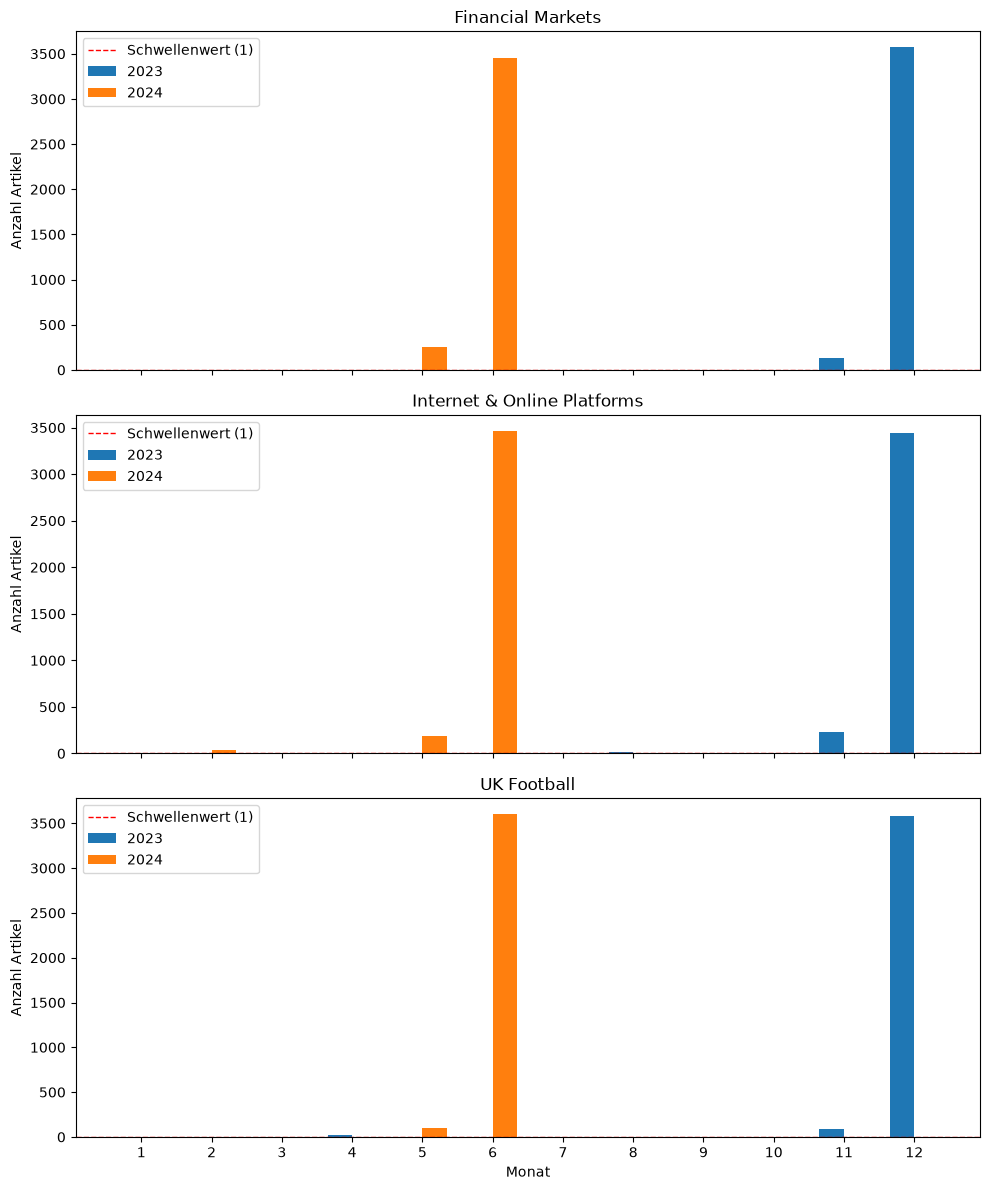

In [24]:
topics = monthly_counts["topic"].unique()
months = range(1, 13)

fig, axes = plt.subplots(len(topics), 1, figsize=(10, 4 * len(topics)), sharex=True)
if len(topics) == 1:
    axes = [axes]

for ax, topic in zip(axes, topics):
    sub = monthly_counts[monthly_counts["topic"] == topic]
    pivot = (
        sub.pivot(index="month", columns="year", values="n_articles")
        .reindex(months)
        .fillna(0)
    )
    x = np.arange(len(months))
    width = 0.35
    if 2023 in pivot.columns:
        ax.bar(x - width / 2, pivot[2023], width, label="2023")
    if 2024 in pivot.columns:
        ax.bar(x + width / 2, pivot[2024], width, label="2024")
    ax.axhline(DENSITY_THRESHOLD, color="red", linestyle="--", linewidth=1,
               label=f"Schwellenwert ({DENSITY_THRESHOLD})")
    ax.set_title(topic)
    ax.set_xticks(x)
    ax.set_xticklabels([str(m) for m in months])
    ax.set_ylabel("Anzahl Artikel")
    ax.legend()

axes[-1].set_xlabel("Monat")
plt.tight_layout()
plt.show()
